## 1) Setup

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

## 2) Chargement du dataset

In [3]:
df = pd.read_csv("cybersecurity_intrusion_data.csv")

In [4]:
df.columns

Index(['session_id', 'network_packet_size', 'protocol_type', 'login_attempts',
       'session_duration', 'encryption_used', 'ip_reputation_score',
       'failed_logins', 'browser_type', 'unusual_time_access',
       'attack_detected'],
      dtype='str')

In [6]:
df.isna().sum() # fait la somme des valeurs nuls dans les colonnes

session_id                0
network_packet_size       0
protocol_type             0
login_attempts            0
session_duration          0
encryption_used        1966
ip_reputation_score       0
failed_logins             0
browser_type              0
unusual_time_access       0
attack_detected           0
dtype: int64

In [7]:
def df_clean():
    df_c = df.copy()
    
    # Toujours opérer sur df_c, pas df
    # get_dummies supprime déjà la colonne originale, pas besoin de drop()
    df_c = pd.get_dummies(df_c, columns=['encryption_used'], prefix='is')
    df_c = pd.get_dummies(df_c, columns=['browser_type'], prefix='used')
    df_c = pd.get_dummies(df_c, columns=['protocol_type'], prefix='used')
    
    return df_c

df_cleaned = df_clean()
df_cleaned.head(10)

,session_id,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,is_AES,is_DES,used_Chrome,used_Edge,used_Firefox,used_Safari,used_Unknown,used_ICMP,used_TCP,used_UDP
0,SID_00001,599,4,492.983263,0.606818,1,0,1,False,True,False,True,False,False,False,False,True,False
1,SID_00002,472,3,1557.996461,0.301569,0,0,0,False,True,False,False,True,False,False,False,True,False
2,SID_00003,629,3,75.044262,0.739164,2,0,1,False,True,True,False,False,False,False,False,True,False
3,SID_00004,804,4,601.248835,0.123267,0,0,1,False,True,False,False,False,False,True,False,False,True
4,SID_00005,453,5,532.540888,0.054874,1,0,0,True,False,False,False,True,False,False,False,True,False
5,SID_00006,453,5,380.471550,0.422486,2,1,0,True,False,True,False,False,False,False,False,False,True
6,SID_00007,815,4,728.107165,0.413772,1,0,1,True,False,True,False,False,False,False,True,False,False
7,SID_00008,653,3,12.599906,0.097719,3,1,1,False,True,True,False,False,False,False,False,True,False
8,SID_00009,406,2,542.558895,0.294580,0,1,0,False,False,True,False,False,False,False,False,True,False
9,SID_00010,608,6,531.944107,0.424117,1,0,0,False,False,True,False,False,False,False,False,False,True


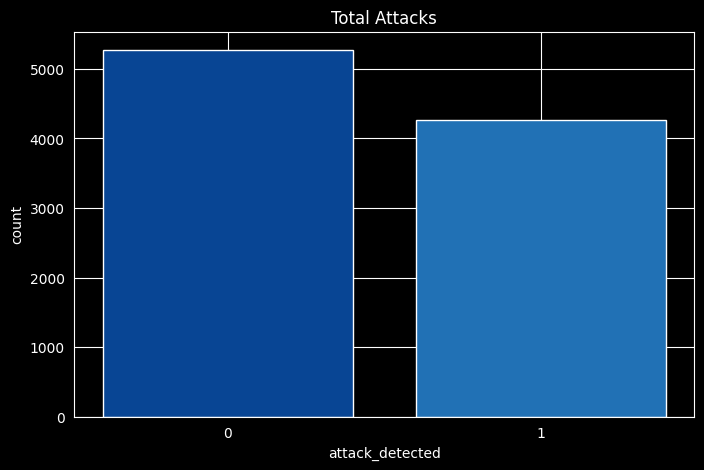

In [8]:
attack_counts = df['attack_detected'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(attack_counts.index.astype(str), attack_counts.values, color=['#084594', '#2171b5', '#6baed6'])
plt.title("Total Attacks")
plt.xlabel("attack_detected")
plt.ylabel("count")
plt.show()

In [9]:
df.drop(columns=['session_id'], inplace=True)

In [10]:
df.head(1)

,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1


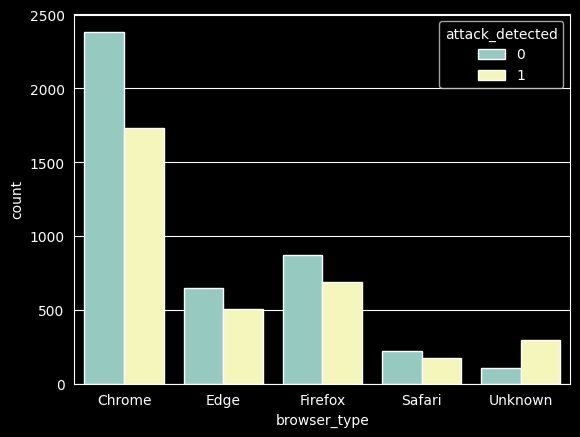

In [11]:
X = df.drop(columns=['attack_detected'])
y = df['attack_detected']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

sns.countplot(data=X_train, x='browser_type', hue=y_train)
plt.show()

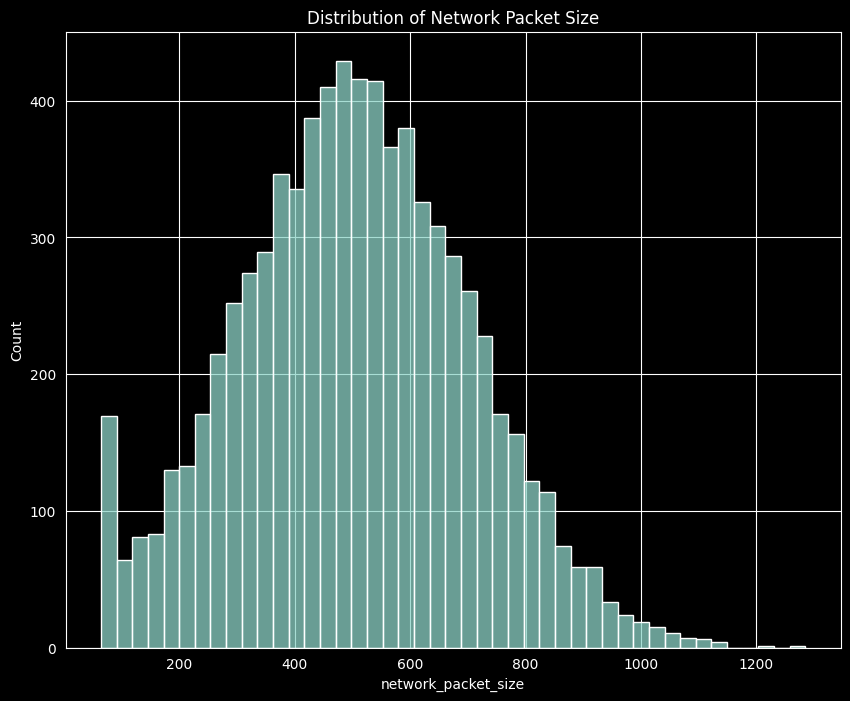

In [12]:
plt.figure(figsize=(10,8))
sns.histplot(x='network_packet_size',data=X_train)
plt.title('Distribution of Network Packet Size')
plt.show()

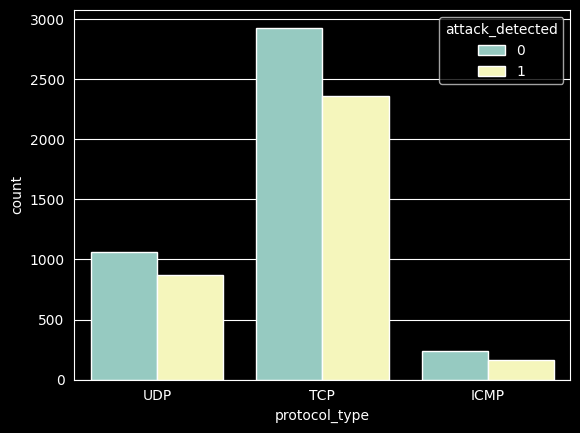

In [13]:
sns.countplot(data=X_train, x='protocol_type', hue=y_train)
plt.show()

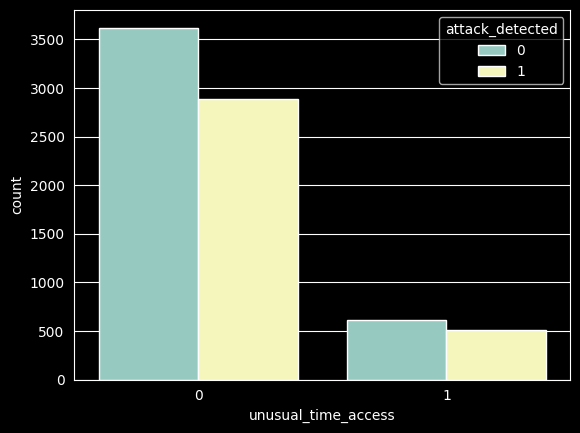

In [14]:
sns.countplot(data=X_train , x='unusual_time_access', hue=y_train)
plt.show()

In [30]:
# Code ici
